In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import (
    make_classification,
    make_circles,
    make_moons,
    load_breast_cancer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Library berhasil diimpor!")

Library berhasil diimpor!


# Pertemuan 5: Support Vector Machine (SVM)

## Tujuan Pembelajaran

Pada praktikum ini akan dipelajari:

1. Konsep dasar Support Vector Machine (SVM)
2. Perbedaan Linear dan Non-Linear SVM
3. Penggunaan berbagai kernel SVM
4. Konsep margin, support vectors, dan hyperplane
5. Pengaruh parameter C dan gamma
6. Parameter tuning menggunakan Grid Search
7. Perbandingan performa berbagai kernel

## Teori Singkat

Support Vector Machine (SVM) adalah algoritma supervised learning yang digunakan untuk klasifikasi dengan mencari hyperplane terbaik untuk memisahkan kelas.

### Konsep penting:
- **Hyperplane**: batas pemisah antar kelas.
- **Margin**: jarak antara hyperplane dengan data terdekat.
- **Support Vectors**: data yang berada paling dekat dengan hyperplane.
- **C**: mengatur seberapa ketat model terhadap kesalahan klasifikasi.
- **Gamma**: mengatur kompleksitas batas keputusan pada kernel RBF.

### Kernel:
- **Linear**: untuk data yang dapat dipisahkan secara linear.
- **Polynomial**: untuk hubungan yang bersifat polynomial.
- **RBF**: untuk data non-linear.
- **Sigmoid**: menggunakan fungsi sigmoid dan relatif jarang digunakan.

Jumlah data : 200
Jumlah fitur: 2
Jumlah kelas: 2


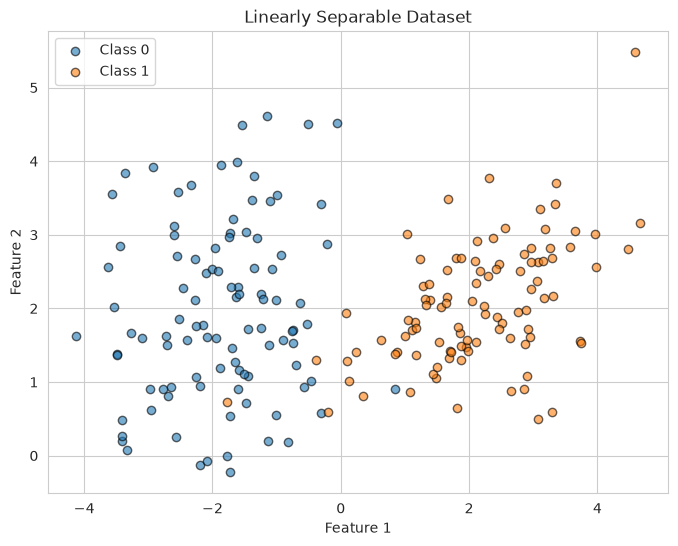

In [2]:
# Generate data yang dapat dipisahkan secara linear
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

print("Jumlah data :", X.shape[0])
print("Jumlah fitur:", X.shape[1])
print("Jumlah kelas:", len(np.unique(y)))

plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0][:, 0],
    X[y == 0][:, 1],
    label='Class 0',
    alpha=0.6,
    edgecolors='k'
)

plt.scatter(
    X[y == 1][:, 0],
    X[y == 1][:, 1],
    label='Class 1',
    alpha=0.6,
    edgecolors='k'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linearly Separable Dataset')
plt.legend()
plt.show()

In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardisasi
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear SVM
svm_linear = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)

svm_linear.fit(X_train_scaled, y_train)

# Prediksi
y_pred = svm_linear.predict(X_test_scaled)

# Evaluasi
print("=== Linear SVM ===")
print(f"Training data : {len(X_train)}")
print(f"Testing data  : {len(X_test)}")
print(f"Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
print(f"Support Vectors: {len(svm_linear.support_vectors_)}")
print(f"Support Vector Index: {svm_linear.support_}")

=== Linear SVM ===
Training data : 160
Testing data  : 40
Accuracy      : 1.0000
Support Vectors: 23
Support Vector Index: [ 15  16  33  35  39  75 103 113 114 118 121 149   1   3  13  23  28  31
  34  41  96 101 156]


In [4]:
def plot_svm_boundary(model, X, y, scaler=None, title='SVM Decision Boundary'):
    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    mesh_input = np.c_[xx.ravel(), yy.ravel()]

    if scaler is not None:
        mesh_input = scaler.transform(mesh_input)

    Z = model.predict(mesh_input)
    Z = Z.reshape(xx.shape)

    plt.contourf(
        xx, yy, Z,
        alpha=0.3,
        cmap='RdYlBu'
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors='k',
        cmap='RdYlBu',
        s=50
    )

    if scaler is not None:
        sv = scaler.inverse_transform(model.support_vectors_)
    else:
        sv = model.support_vectors_

    plt.scatter(
        sv[:, 0],
        sv[:, 1],
        s=200,
        linewidth=1.5,
        facecolors='none',
        edgecolors='k',
        label='Support Vectors'
    )

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()

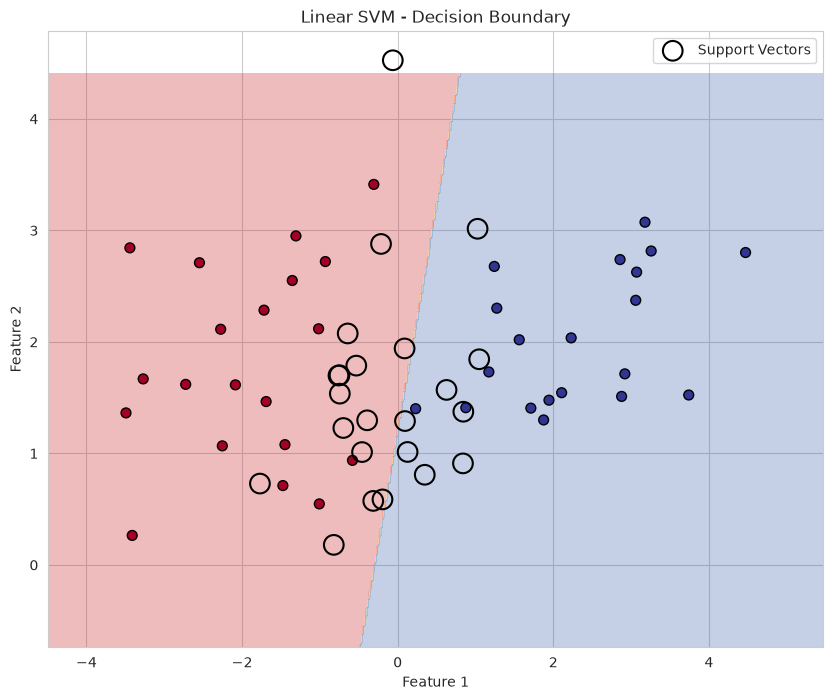

In [5]:
plt.figure(figsize=(10, 8))

plot_svm_boundary(
    svm_linear,
    X_test,
    y_test,
    scaler,
    'Linear SVM - Decision Boundary'
)

plt.show()

## Interpretasi Linear SVM

Hasil Linear SVM menunjukkan bahwa model mampu memisahkan dua kelas dengan sangat baik. Accuracy yang diperoleh sebesar 100% pada data testing.

Support vectors adalah titik data yang paling dekat dengan hyperplane dan berperan penting dalam menentukan batas pemisah antar kelas.

Jumlah data: 300
Jumlah fitur: 2


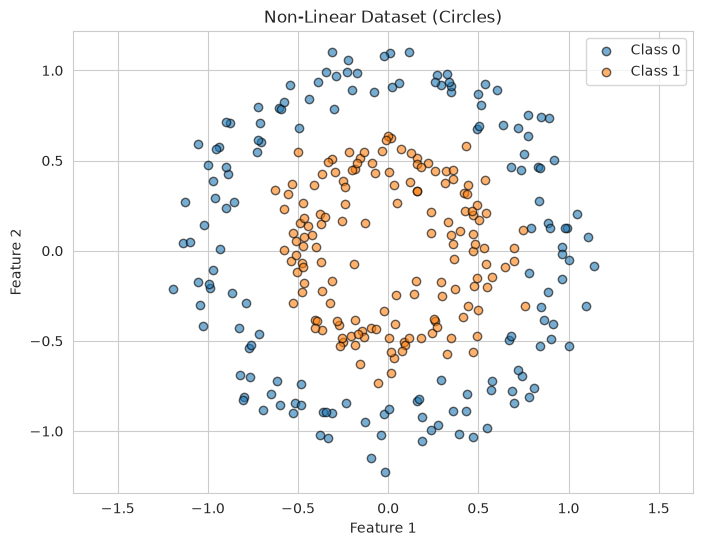

In [6]:
# Membuat dataset berbentuk lingkaran
X_circles, y_circles = make_circles(
    n_samples=300,
    noise=0.1,
    factor=0.5,
    random_state=42
)

print("Jumlah data:", X_circles.shape[0])
print("Jumlah fitur:", X_circles.shape[1])

plt.figure(figsize=(8, 6))

plt.scatter(
    X_circles[y_circles == 0][:, 0],
    X_circles[y_circles == 0][:, 1],
    label='Class 0',
    alpha=0.6,
    edgecolors='k'
)

plt.scatter(
    X_circles[y_circles == 1][:, 0],
    X_circles[y_circles == 1][:, 1],
    label='Class 1',
    alpha=0.6,
    edgecolors='k'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Non-Linear Dataset (Circles)')
plt.legend()
plt.axis('equal')
plt.show()

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_circles,
    y_circles,
    test_size=0.2,
    random_state=42,
    stratify=y_circles
)

# Standardisasi
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Membuat dua model
svm_linear_circle = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)

svm_rbf_circle = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

# Training
svm_linear_circle.fit(X_train_scaled, y_train)
svm_rbf_circle.fit(X_train_scaled, y_train)

# Prediksi
pred_linear = svm_linear_circle.predict(X_test_scaled)
pred_rbf = svm_rbf_circle.predict(X_test_scaled)

# Evaluasi
acc_linear = accuracy_score(y_test, pred_linear)
acc_rbf = accuracy_score(y_test, pred_rbf)

print("=== Perbandingan Linear vs RBF ===")
print(f"Linear SVM Accuracy : {acc_linear:.4f}")
print(f"RBF SVM Accuracy    : {acc_rbf:.4f}")
print()
print(f"Linear Support Vectors: {len(svm_linear_circle.support_vectors_)}")
print(f"RBF Support Vectors   : {len(svm_rbf_circle.support_vectors_)}")

=== Perbandingan Linear vs RBF ===
Linear SVM Accuracy : 0.5167
RBF SVM Accuracy    : 1.0000

Linear Support Vectors: 234
RBF Support Vectors   : 55


In [8]:
# Load dataset Breast Cancer
cancer = load_breast_cancer()

X_breast = cancer.data
y_breast = cancer.target

print("=== Breast Cancer Dataset ===")
print("Jumlah data   :", X_breast.shape[0])
print("Jumlah fitur  :", X_breast.shape[1])
print("Nama kelas    :", cancer.target_names)

print("\nDistribusi kelas:")
print(pd.Series(y_breast).value_counts().sort_index())

=== Breast Cancer Dataset ===
Jumlah data   : 569
Jumlah fitur  : 30
Nama kelas    : ['malignant' 'benign']

Distribusi kelas:
0    212
1    357
Name: count, dtype: int64


In [9]:
# Split data 80% training dan 20% testing
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_breast,
    y_breast,
    test_size=0.2,
    random_state=42,
    stratify=y_breast
)

# Standardisasi
scaler_b = StandardScaler()

X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

print("=== Pembagian Data ===")
print("Data training:", X_train_b.shape[0])
print("Data testing :", X_test_b.shape[0])
print("Jumlah fitur :", X_train_b.shape[1])

=== Pembagian Data ===
Data training: 455
Data testing : 114
Jumlah fitur : 30


In [10]:
# Membuat tiga model SVM
svm_models = {
    'Linear': SVC(
        kernel='linear',
        C=1.0,
        random_state=42
    ),
    
    'Polynomial': SVC(
        kernel='poly',
        C=1.0,
        gamma='scale',
        random_state=42
    ),
    
    'RBF': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42
    )
}

# Training semua model
results_kernel = []

for name, model in svm_models.items():
    model.fit(X_train_b_scaled, y_train_b)
    
    y_pred = model.predict(X_test_b_scaled)
    
    results_kernel.append({
        'Kernel': name,
        'Accuracy': accuracy_score(y_test_b, y_pred),
        'Precision': precision_score(y_test_b, y_pred),
        'Recall': recall_score(y_test_b, y_pred),
        'Support Vectors': len(model.support_vectors_)
    })

results_kernel_df = pd.DataFrame(results_kernel)

print("=== Perbandingan Kernel SVM ===")
print(results_kernel_df.to_string(index=False))

=== Perbandingan Kernel SVM ===
    Kernel  Accuracy  Precision   Recall  Support Vectors
    Linear  0.973684   0.985915 0.972222               32
Polynomial  0.912281   0.878049 1.000000              145
       RBF  0.982456   0.986111 0.986111               97


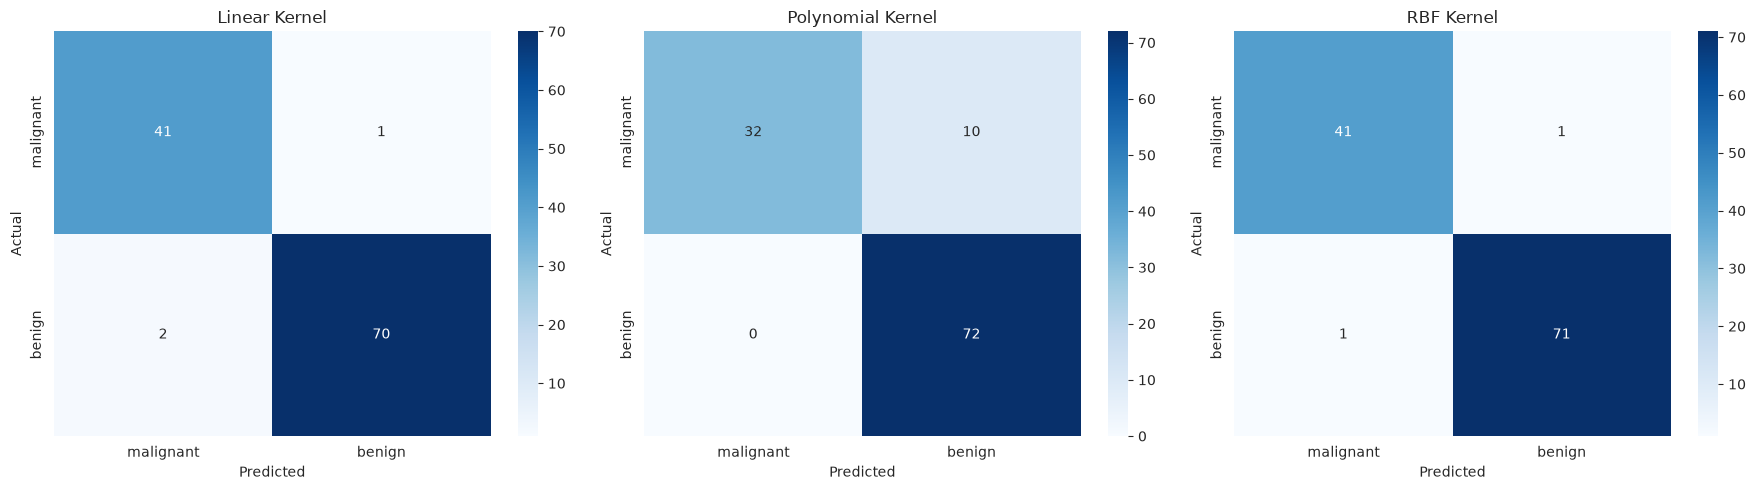

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(svm_models.items()):
    y_pred = model.predict(X_test_b_scaled)
    
    cm = confusion_matrix(y_test_b, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=cancer.target_names,
        yticklabels=cancer.target_names
    )
    
    axes[idx].set_title(f'{name} Kernel')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [12]:
# Menentukan kernel terbaik berdasarkan accuracy
best_kernel_row = results_kernel_df.loc[
    results_kernel_df['Accuracy'].idxmax()
]

print("=== Kernel Terbaik ===")
print("Kernel   :", best_kernel_row['Kernel'])
print(f"Accuracy : {best_kernel_row['Accuracy']:.4f}")
print(f"Precision: {best_kernel_row['Precision']:.4f}")
print(f"Recall   : {best_kernel_row['Recall']:.4f}")
print("Support Vectors:", int(best_kernel_row['Support Vectors']))

=== Kernel Terbaik ===
Kernel   : RBF
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
Support Vectors: 97


In [13]:
# Menggunakan dataset Breast Cancer yang sudah dibagi sebelumnya

C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

tuning_results = []

print("C values    :", C_values)
print("Gamma values:", gamma_values)
print("Total kombinasi:", len(C_values) * len(gamma_values))

C values    : [0.01, 0.1, 1, 10, 100]
Gamma values: [0.001, 0.01, 0.1, 1, 10]
Total kombinasi: 25


In [14]:
for C in C_values:
    for gamma in gamma_values:
        
        svm_model = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma,
            random_state=42
        )
        
        svm_model.fit(X_train_b_scaled, y_train_b)
        
        train_pred = svm_model.predict(X_train_b_scaled)
        test_pred = svm_model.predict(X_test_b_scaled)
        
        train_accuracy = accuracy_score(y_train_b, train_pred)
        test_accuracy = accuracy_score(y_test_b, test_pred)
        
        tuning_results.append({
            'C': C,
            'Gamma': gamma,
            'Training Accuracy': train_accuracy,
            'Testing Accuracy': test_accuracy,
            'Support Vectors': len(svm_model.support_vectors_)
        })

tuning_df = pd.DataFrame(tuning_results)

print("=== Hasil Parameter Tuning ===")
print(tuning_df.to_string(index=False))

=== Hasil Parameter Tuning ===
     C  Gamma  Training Accuracy  Testing Accuracy  Support Vectors
  0.01  0.001           0.626374          0.631579              340
  0.01  0.010           0.626374          0.631579              341
  0.01  0.100           0.626374          0.631579              344
  0.01  1.000           0.626374          0.631579              454
  0.01 10.000           0.626374          0.631579              455
  0.10  0.001           0.806593          0.798246              334
  0.10  0.010           0.951648          0.956140              201
  0.10  0.100           0.971429          0.947368              289
  0.10  1.000           0.626374          0.631579              454
  0.10 10.000           0.626374          0.631579              455
  1.00  0.001           0.951648          0.956140              172
  1.00  0.010           0.982418          0.982456               94
  1.00  0.100           0.989011          0.956140              183
  1.00  1.000    

In [15]:
best_tuning = tuning_df.loc[
    tuning_df['Testing Accuracy'].idxmax()
]

print("=== Kombinasi Terbaik ===")
print("C                 :", best_tuning['C'])
print("Gamma             :", best_tuning['Gamma'])
print(f"Training Accuracy : {best_tuning['Training Accuracy']:.4f}")
print(f"Testing Accuracy  : {best_tuning['Testing Accuracy']:.4f}")
print("Support Vectors   :", int(best_tuning['Support Vectors']))

=== Kombinasi Terbaik ===
C                 : 1.0
Gamma             : 0.01
Training Accuracy : 0.9824
Testing Accuracy  : 0.9825
Support Vectors   : 94


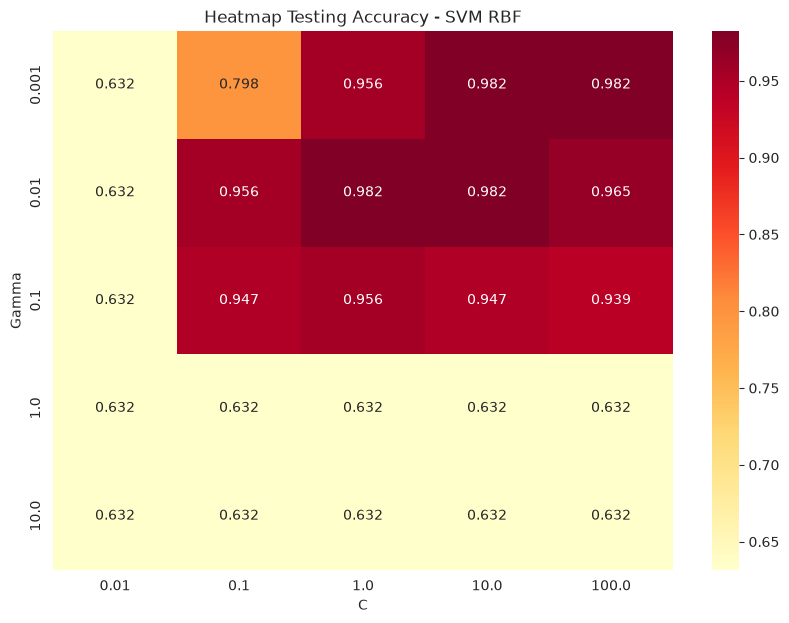

In [16]:
heatmap_test = tuning_df.pivot(
    index='Gamma',
    columns='C',
    values='Testing Accuracy'
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    heatmap_test,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd'
)

plt.title('Heatmap Testing Accuracy - SVM RBF')
plt.xlabel('C')
plt.ylabel('Gamma')
plt.show()

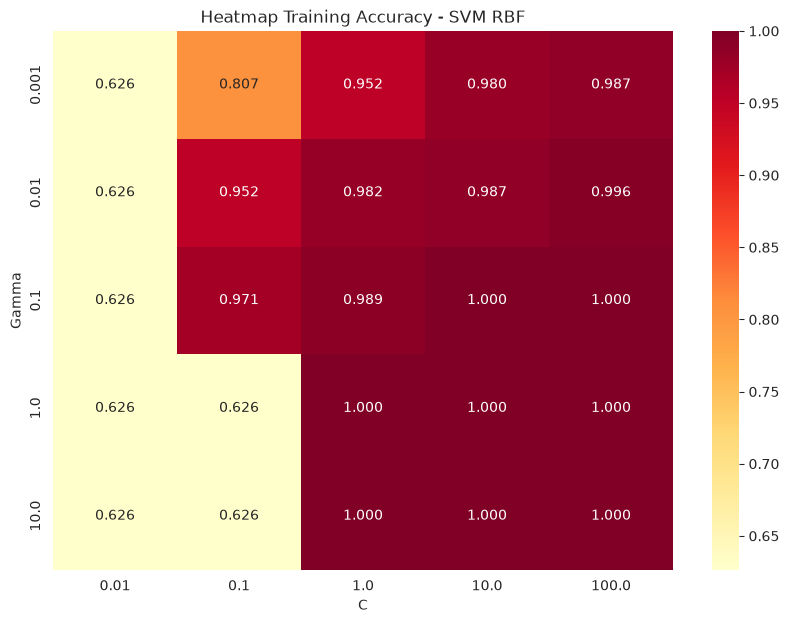

In [17]:
heatmap_train = tuning_df.pivot(
    index='Gamma',
    columns='C',
    values='Training Accuracy'
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    heatmap_train,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd'
)

plt.title('Heatmap Training Accuracy - SVM RBF')
plt.xlabel('C')
plt.ylabel('Gamma')
plt.show()

In [18]:
# Dataset 1: Circles
X_circles, y_circles = make_circles(
    n_samples=300,
    noise=0.1,
    factor=0.5,
    random_state=42
)

# Dataset 2: Moons
X_moons, y_moons = make_moons(
    n_samples=300,
    noise=0.15,
    random_state=42
)

# Dataset 3: XOR
X_xor = np.random.RandomState(42).uniform(-1, 1, (300, 2))
y_xor = ((X_xor[:, 0] * X_xor[:, 1]) > 0).astype(int)

print("Dataset Circles:", X_circles.shape)
print("Dataset Moons  :", X_moons.shape)
print("Dataset XOR    :", X_xor.shape)

Dataset Circles: (300, 2)
Dataset Moons  : (300, 2)
Dataset XOR    : (300, 2)


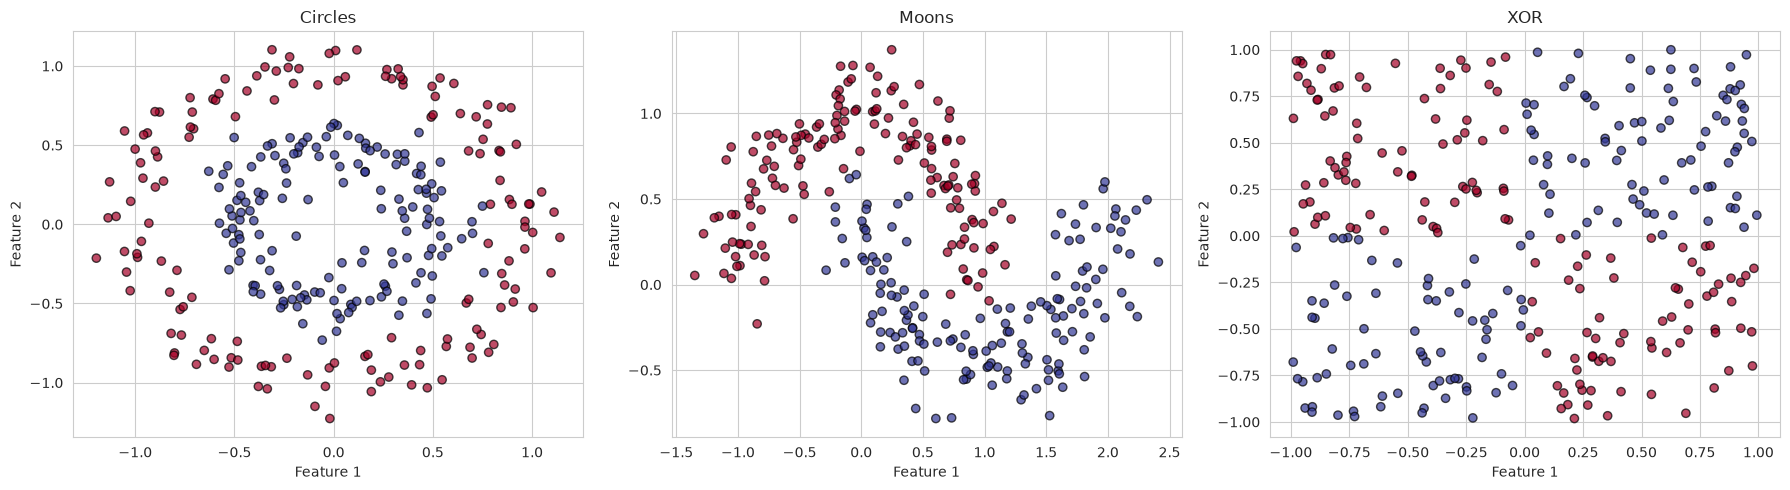

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (X_circles, y_circles, 'Circles'),
    (X_moons, y_moons, 'Moons'),
    (X_xor, y_xor, 'XOR')
]

for ax, (X_data, y_data, title) in zip(axes, datasets):
    ax.scatter(
        X_data[:, 0],
        X_data[:, 1],
        c=y_data,
        cmap='RdYlBu',
        edgecolors='k',
        alpha=0.7
    )
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

In [20]:
def plot_kernel_boundary(model, X, y, ax, title):
    h = 0.02

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap='RdYlBu'
    )

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap='RdYlBu',
        edgecolors='k',
        s=25
    )

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

In [21]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

dataset_list = [
    ('Circles', X_circles, y_circles),
    ('Moons', X_moons, y_moons),
    ('XOR', X_xor, y_xor)
]

kernel_results = []

for dataset_name, X_data, y_data in dataset_list:
    
    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
        X_data,
        y_data,
        test_size=0.2,
        random_state=42,
        stratify=y_data
    )
    
    scaler_k = StandardScaler()
    
    X_train_k = scaler_k.fit_transform(X_train_k)
    X_test_k = scaler_k.transform(X_test_k)
    
    for kernel in kernels:
        
        model = SVC(
            kernel=kernel,
            C=1.0,
            gamma='scale',
            random_state=42
        )
        
        model.fit(X_train_k, y_train_k)
        
        train_pred = model.predict(X_train_k)
        test_pred = model.predict(X_test_k)
        
        kernel_results.append({
            'Dataset': dataset_name,
            'Kernel': kernel,
            'Training Accuracy': accuracy_score(y_train_k, train_pred),
            'Testing Accuracy': accuracy_score(y_test_k, test_pred),
            'Support Vectors': len(model.support_vectors_)
        })

kernel_results_df = pd.DataFrame(kernel_results)

print("=== Hasil 12 Kombinasi ===")
print(kernel_results_df.to_string(index=False))

=== Hasil 12 Kombinasi ===
Dataset  Kernel  Training Accuracy  Testing Accuracy  Support Vectors
Circles  linear           0.562500          0.516667              234
Circles    poly           0.687500          0.700000              233
Circles     rbf           0.987500          1.000000               55
Circles sigmoid           0.545833          0.566667              143
  Moons  linear           0.883333          0.800000               64
  Moons    poly           0.908333          0.800000               71
  Moons     rbf           0.970833          0.966667               56
  Moons sigmoid           0.741667          0.733333               78
    XOR  linear           0.662500          0.666667              226
    XOR    poly           0.579167          0.633333              225
    XOR     rbf           0.970833          0.933333               75
    XOR sigmoid           0.541667          0.650000              144


In [22]:
print("=== Kernel Terbaik Setiap Dataset ===")

best_each_dataset = (
    kernel_results_df
    .loc[
        kernel_results_df.groupby('Dataset')['Testing Accuracy'].idxmax()
    ]
    .reset_index(drop=True)
)

print(best_each_dataset.to_string(index=False))

=== Kernel Terbaik Setiap Dataset ===
Dataset Kernel  Training Accuracy  Testing Accuracy  Support Vectors
Circles    rbf           0.987500          1.000000               55
  Moons    rbf           0.970833          0.966667               56
    XOR    rbf           0.970833          0.933333               75


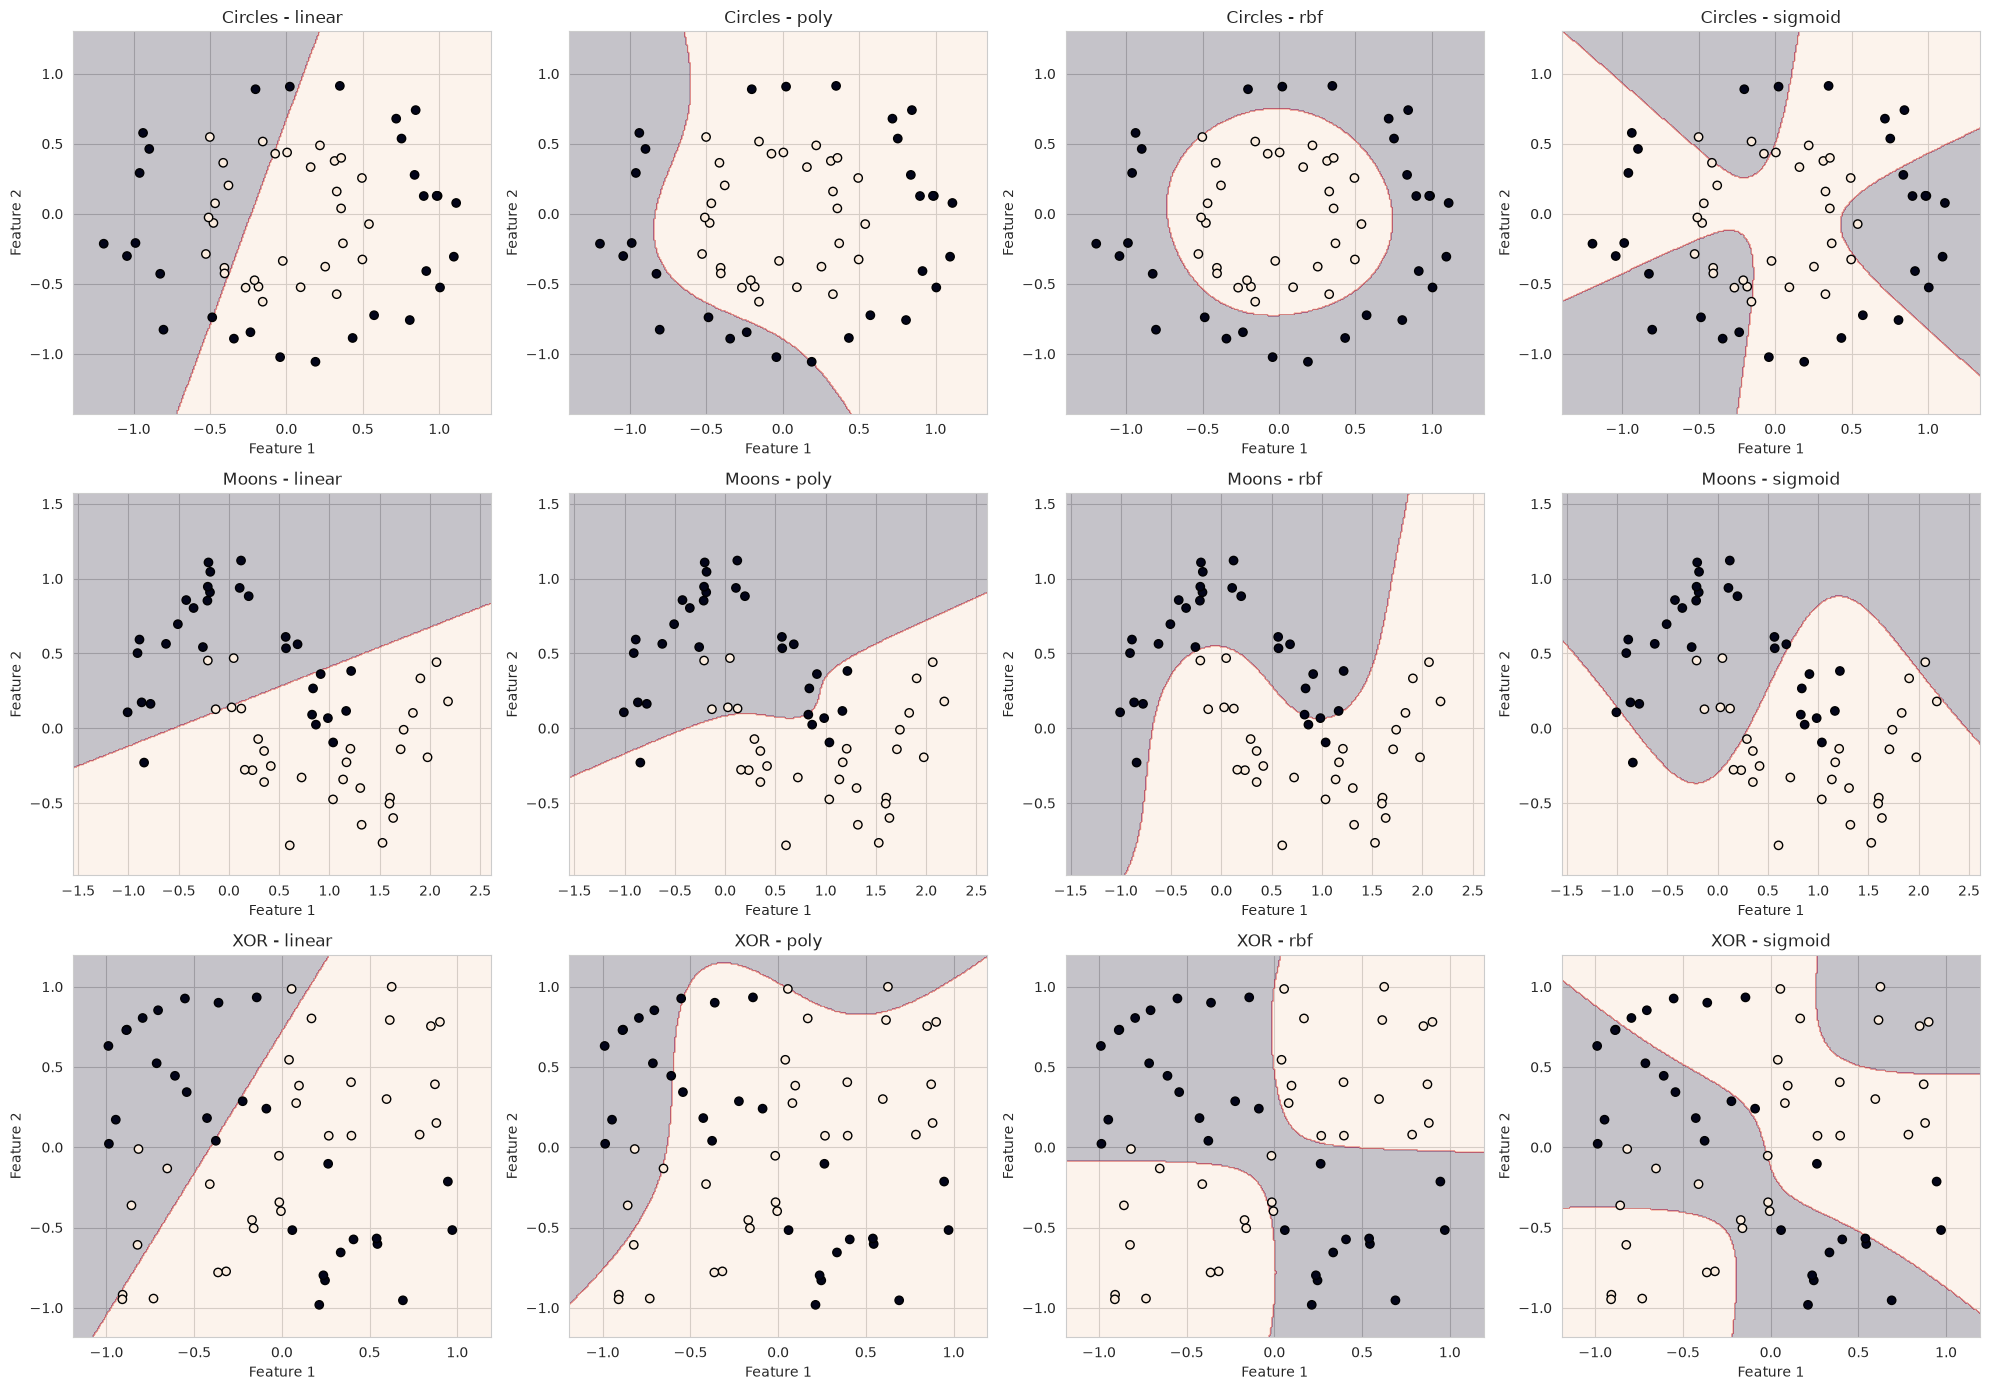

In [23]:
# Visualisasi 12 decision boundary
datasets = {
    'Circles': (X_circles, y_circles),
    'Moons': (X_moons, y_moons),
    'XOR': (X_xor, y_xor)
}

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))

for i, (dataset_name, (X, y)) in enumerate(datasets.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for j, kernel in enumerate(kernels):
        model = SVC(kernel=kernel, C=1, gamma='scale')
        model.fit(X_train_scaled, y_train)

        # Buat mesh berdasarkan data asli
        x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
        y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300),
            np.linspace(y_min, y_max, 300)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]
        grid_scaled = scaler.transform(grid)

        Z = model.predict(grid_scaled)
        Z = Z.reshape(xx.shape)

        ax = axes[i, j]

        ax.contourf(xx, yy, Z, alpha=0.25)
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            edgecolors='k'
        )

        ax.set_title(f'{dataset_name} - {kernel}')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

Kernel,linear,poly,rbf,sigmoid
Dataset,,,,
Circles,0.516667,0.700000,1.000000,0.566667
Moons,0.800000,0.800000,0.966667,0.733333
XOR,0.666667,0.633333,0.933333,0.650000


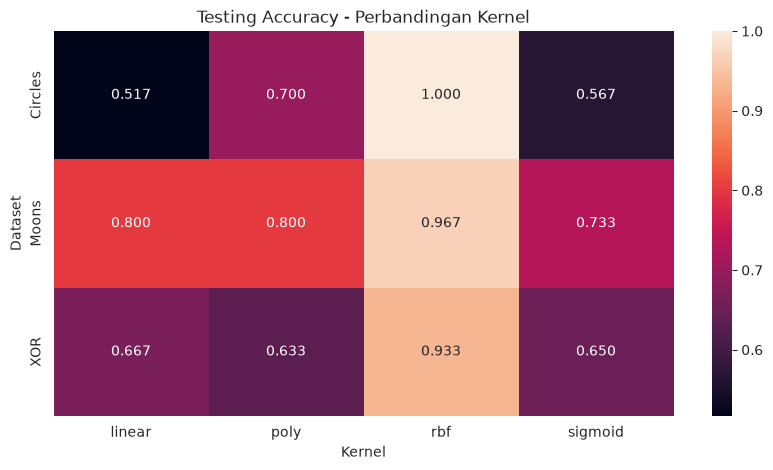

In [24]:
# Membuat tabel perbandingan akurasi
pivot_accuracy = kernel_results_df.pivot(
    index='Dataset',
    columns='Kernel',
    values='Testing Accuracy'
)

display(pivot_accuracy)

plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_accuracy,
    annot=True,
    fmt='.3f'
)

plt.title('Testing Accuracy - Perbandingan Kernel')
plt.xlabel('Kernel')
plt.ylabel('Dataset')
plt.show()

### Analisis Tugas 3

Berdasarkan percobaan pada tiga dataset non-linear yaitu Circles, Moons, dan XOR, kernel RBF memberikan hasil terbaik pada seluruh dataset.

Pada dataset Circles, RBF memperoleh testing accuracy sebesar 100%. Pada dataset Moons, RBF memperoleh 96,67%, sedangkan pada dataset XOR memperoleh 93,33%.

Kernel linear memiliki performa yang lebih rendah karena batas keputusan yang dihasilkan hanya berbentuk garis lurus. Kernel RBF lebih cocok untuk data non-linear karena mampu membentuk batas keputusan yang lebih fleksibel.

Dari hasil tersebut dapat disimpulkan bahwa RBF merupakan kernel yang paling sesuai untuk ketiga dataset yang diuji pada percobaan ini.

In [25]:
# Memuat dataset Breast Cancer
data = load_breast_cancer()

X = data.data
y = data.target

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])
print("Jumlah fitur         :", X_train.shape[1])

Jumlah data training : 455
Jumlah data testing  : 114
Jumlah fitur         : 30


In [26]:
from sklearn.pipeline import Pipeline

# Pipeline: scaling dilakukan di dalam proses Grid Search
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

# Parameter yang akan diuji
param_grid = {
    'svc__C': [0.01, 0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1, 10],
    'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

print("Jumlah kombinasi parameter:", 
      5 * 5 * 4)

Jumlah kombinasi parameter: 100


In [27]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Grid Search selesai!")
print("Best Parameters:")
print(grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Grid Search selesai!
Best Parameters:
{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best CV Accuracy: 0.9802197802197803


In [28]:
# Menggunakan model terbaik hasil Grid Search
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("=== HASIL MODEL TERBAIK ===")
print("Best Parameters :", grid_search.best_params_)
print("CV Accuracy     :", round(grid_search.best_score_, 4))
print("Test Accuracy   :", round(test_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

=== HASIL MODEL TERBAIK ===
Best Parameters : {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
CV Accuracy     : 0.9802
Test Accuracy   : 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



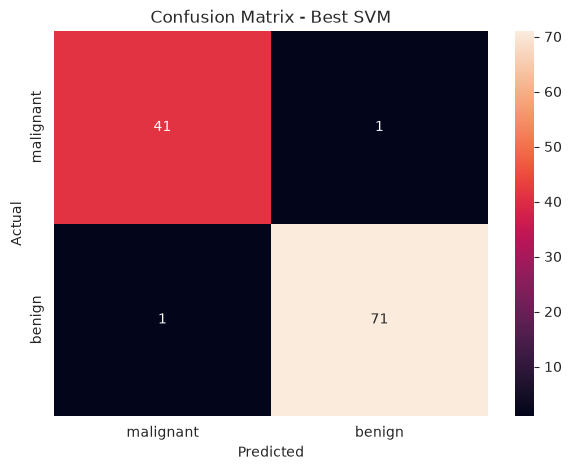

Confusion Matrix:
[[41  1]
 [ 1 71]]


In [29]:
# Confusion Matrix Model Terbaik

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.title('Confusion Matrix - Best SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print(cm)

In [30]:
# Perbandingan dengan hasil tuning sebelumnya
# Hasil terbaik Tugas 2 = C=1, gamma=0.01
accuracy_sebelum = 0.982456
accuracy_sesudah = test_accuracy

peningkatan = accuracy_sesudah - accuracy_sebelum

print("=== PERBANDINGAN MODEL ===")
print(f"Akurasi sebelum Grid Search : {accuracy_sebelum:.4f}")
print(f"Akurasi sesudah Grid Search : {accuracy_sesudah:.4f}")
print(f"Peningkatan                 : {peningkatan:.4f}")

=== PERBANDINGAN MODEL ===
Akurasi sebelum Grid Search : 0.9825
Akurasi sesudah Grid Search : 0.9825
Peningkatan                 : 0.0000


### Kesimpulan Tugas 4

Grid Search digunakan untuk mencari kombinasi parameter SVM yang paling baik. Dari 100 kombinasi parameter yang diuji dengan 5-fold cross-validation, diperoleh parameter terbaik yaitu C=10, gamma=0.01, dan kernel RBF.

Model terbaik memperoleh CV Accuracy sebesar 98,02% dan Test Accuracy sebesar 98,25%. Hasil precision, recall, dan F1-score juga berada pada kisaran 98–99%.

Hasil ini menunjukkan bahwa Grid Search berhasil menemukan konfigurasi SVM yang memiliki performa sangat baik pada dataset Breast Cancer. Namun, peningkatan akurasi dibandingkan model tuning sebelumnya sangat kecil, sehingga optimasi tidak memberikan peningkatan yang signifikan pada test accuracy.

# KESIMPULAN AKHIR PERTEMUAN 5

Pada praktikum ini telah dipelajari algoritma Support Vector Machine (SVM), mulai dari konsep hyperplane, margin, support vector, kernel, hingga tuning parameter.

Pada percobaan Linear SVM, model mampu bekerja sangat baik pada data yang memiliki pola linear. Namun, untuk data non-linear seperti Circles, Moons, dan XOR, kernel RBF memberikan hasil yang lebih baik.

Pada tuning parameter, nilai C dan gamma sangat memengaruhi performa SVM. Nilai yang terlalu kecil dapat menyebabkan underfitting, sedangkan kombinasi tertentu dengan gamma besar dapat menyebabkan overfitting.

Pada Grid Search, kombinasi terbaik pada dataset Breast Cancer adalah C=10, gamma=0.01, dan kernel RBF. Model memperoleh CV Accuracy 98,02% dan Test Accuracy 98,25%.

Secara keseluruhan, kernel RBF menjadi pilihan terbaik pada sebagian besar percobaan karena mampu menangani pola data yang tidak linear dengan baik.

# CHECKLIST PERTEMUAN 5

- [x] Memahami konsep dasar SVM
- [x] Mencoba Linear SVM
- [x] Mencoba Non-linear SVM dengan RBF
- [x] Membandingkan Linear dan RBF
- [x] Melakukan tuning parameter C
- [x] Melakukan tuning parameter gamma
- [x] Membandingkan 4 kernel
- [x] Menguji 3 dataset non-linear
- [x] Membuat 12 kombinasi kernel
- [x] Melakukan Grid Search
- [x] Membuat Confusion Matrix
- [x] Mengevaluasi Accuracy, Precision, Recall, dan F1-score
- [x] Membuat kesimpulan

# IDENTITAS

**Nama:** MUH. ALI IMRAN  
**NIM:** 105841113523  
**Program Studi:** Informatika  
**Mata Kuliah:** Applied Machine Learning  

**Pertemuan:** 5  
**Materi:** Support Vector Machine (SVM)

**Nama File Notebook:**

`pertemuan_05_svm.ipynb`

**Nama File PDF:**

`105841113523_MUH_ALI_IMRAN_Pertemuan05.pdf`